## Task 1

In [1]:
import numpy as np
import time

prices = [10, 15, 22, 30, 45, 55, 60, 75, 80, 95,
          100, 120, 135, 150, 175, 200, 225, 250, 275, 300]

# Loop-based tax calculation
taxed_prices_loop = []

for price in prices:
    taxed_prices_loop.append(price * 1.08)

print("Loop-based taxed prices:")
print(taxed_prices_loop)


# Step 2: NumPy Vectorization
price_array = np.array(prices)

taxed_prices_numpy = price_array * 1.08

print("\nNumPy taxed prices:")
print(taxed_prices_numpy)


print("\nResults identical:",
      np.allclose(taxed_prices_loop, taxed_prices_numpy))


# Boolean Masking

threshold = 50
high_prices = taxed_prices_numpy[taxed_prices_numpy > threshold]

print(f"\nTaxed prices greater than {threshold}:")
print(high_prices)


# 2D Array Operations

matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

print("\n2D Array:")
print(matrix)

row_sums = matrix.sum(axis=1)
column_sums = matrix.sum(axis=0)

print("\nRow sums:")
print(row_sums)

print("\nColumn sums:")
print(column_sums)


# Stretch Goal

large_list = list(range(1_000_000))

# Loop timing
start = time.perf_counter()

loop_result = []
for x in large_list:
    loop_result.append(x * 1.08)

loop_time = time.perf_counter() - start


# NumPy timing
large_array = np.array(large_list)
start = time.perf_counter()
numpy_result = large_array * 1.08
numpy_time = time.perf_counter() - start
speedup = loop_time / numpy_time

print("\nPerformance Comparison")
print(f"Loop Time: {loop_time:.6f} seconds")
print(f"NumPy Time: {numpy_time:.6f} seconds")
print(f"Speedup: {speedup:.2f}x")

Loop-based taxed prices:
[10.8, 16.200000000000003, 23.76, 32.400000000000006, 48.6, 59.400000000000006, 64.80000000000001, 81.0, 86.4, 102.60000000000001, 108.0, 129.60000000000002, 145.8, 162.0, 189.0, 216.0, 243.00000000000003, 270.0, 297.0, 324.0]

NumPy taxed prices:
[ 10.8   16.2   23.76  32.4   48.6   59.4   64.8   81.    86.4  102.6
 108.   129.6  145.8  162.   189.   216.   243.   270.   297.   324.  ]

Results identical: True

Taxed prices greater than 50:
[ 59.4  64.8  81.   86.4 102.6 108.  129.6 145.8 162.  189.  216.  243.
 270.  297.  324. ]

2D Array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Row sums:
[10 26 42]

Column sums:
[15 18 21 24]

Performance Comparison
Loop Time: 0.417032 seconds
NumPy Time: 0.008373 seconds
Speedup: 49.81x


## Task 2

In [2]:
import pandas as pd

employees = {
    "name": ["Arun", "Meera", "Rahul", "Anu", "Vishnu",
             "Priya", "Kiran", "Neha", "Adithya", "Sneha",
             "Ravi", "Divya", "Akhil", "Nikhil", "Swetha"],
    "department": ["IT", "HR", "Finance", "IT", "Sales",
                   "HR", "IT", "Finance", "Sales", "IT",
                   "HR", "Finance", "Sales", "IT", "HR"],
    "salary": [55000, 45000, 60000, 70000, 50000,
               48000, 65000, 62000, 58000, 72000,
               52000, 68000, 61000, 75000, 49000],
    "years_experience": [2, 3, 5, 6, 4,
                         3, 5, 7, 6, 8,
                         4, 6, 7, 9, 3]
}

df = pd.DataFrame(employees)

df.to_csv("employees.csv", index=False)

df = pd.read_csv("employees.csv")

print(df.info())
print("\nSummary:")
print(df.describe())


# Filtering using boolean indexing

it_employees = df[df["department"] == "IT"]

print("\nIT employees:")
print(it_employees)


# Filtering using query

it_employees_query = df.query("department == 'IT'")

print("\nIT employees using query:")
print(it_employees_query)


print("\nBoth filtering methods give same rows:")
print(it_employees.reset_index(drop=True).equals(
    it_employees_query.reset_index(drop=True)
))


# Grouping and aggregation

department_summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

department_summary = department_summary.sort_values(
    "average_salary", ascending=False
)

print("\nDepartment Summary:")
print(department_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              15 non-null     object
 1   department        15 non-null     object
 2   salary            15 non-null     int64 
 3   years_experience  15 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 612.0+ bytes
None

Summary:
             salary  years_experience
count     15.000000         15.000000
mean   59333.333333          5.200000
std     9408.709238          2.042408
min    45000.000000          2.000000
25%    51000.000000          3.500000
50%    60000.000000          5.000000
75%    66500.000000          6.500000
max    75000.000000          9.000000

IT employees:
      name department  salary  years_experience
0     Arun         IT   55000                 2
3      Anu         IT   70000                 6
6    Kiran         IT   65000                 5
9  

## Task 3

In [3]:
import pandas as pd
import numpy as np

employees = pd.read_csv("employees.csv")

departments = pd.DataFrame({
    "department": ["IT", "HR", "Finance", "Sales"],
    "department_budget": [500000, 250000, 400000, 350000]
})


# Inner join

inner_join = pd.merge(
    employees,
    departments,
    on="department",
    how="inner"
)

print("Inner Join:")
print(inner_join)


# Adding an employee from a department not in departments

new_employee = pd.DataFrame({
    "name": ["John"],
    "department": ["Marketing"],
    "salary": [55000],
    "years_experience": [4]
})

employees = pd.concat([employees, new_employee], ignore_index=True)


# Left join

left_join = pd.merge(
    employees,
    departments,
    on="department",
    how="left"
)

print("\nLeft Join:")
print(left_join)


# Adding missing values

employees.loc[2, "salary"] = np.nan
employees.loc[5, "years_experience"] = np.nan

print("\nMissing values:")
print(employees.isna().sum())


# Fill missing salary with the average salary because using the mean keeps the employee data without removing a row.

employees["salary"] = employees["salary"].fillna(
    employees["salary"].mean()
)

# Fill missing years of experience with the average because it keeps all employees in the dataset.

employees["years_experience"] = employees["years_experience"].fillna(
    employees["years_experience"].mean()
)

print("\nData after handling missing values:")
print(employees)

Inner Join:
       name department  salary  years_experience  department_budget
0      Arun         IT   55000                 2             500000
1     Meera         HR   45000                 3             250000
2     Rahul    Finance   60000                 5             400000
3       Anu         IT   70000                 6             500000
4    Vishnu      Sales   50000                 4             350000
5     Priya         HR   48000                 3             250000
6     Kiran         IT   65000                 5             500000
7      Neha    Finance   62000                 7             400000
8   Adithya      Sales   58000                 6             350000
9     Sneha         IT   72000                 8             500000
10     Ravi         HR   52000                 4             250000
11    Divya    Finance   68000                 6             400000
12    Akhil      Sales   61000                 7             350000
13   Nikhil         IT   75000      

## Task 4

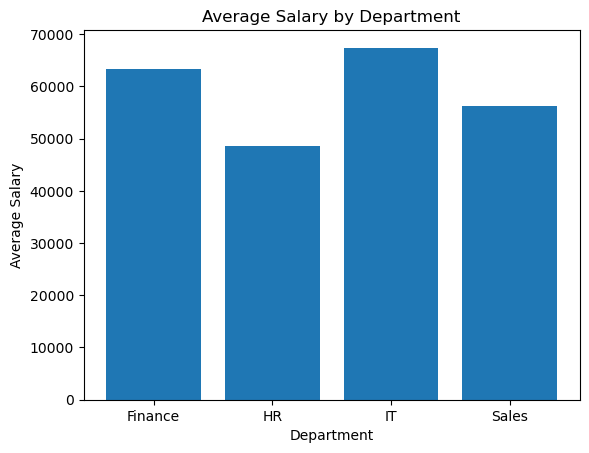

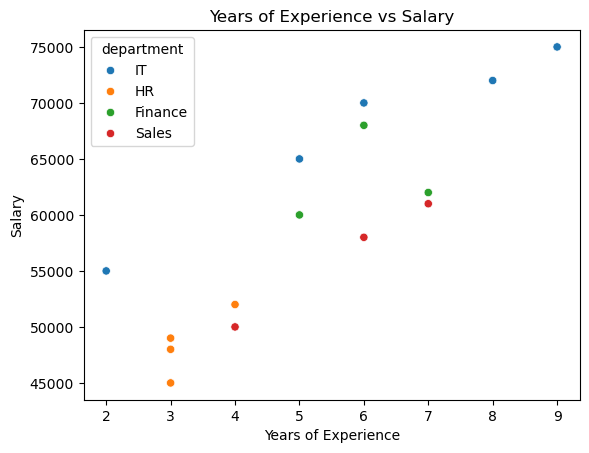

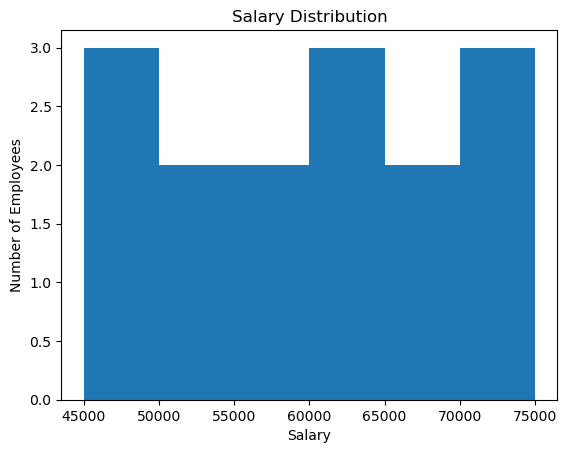

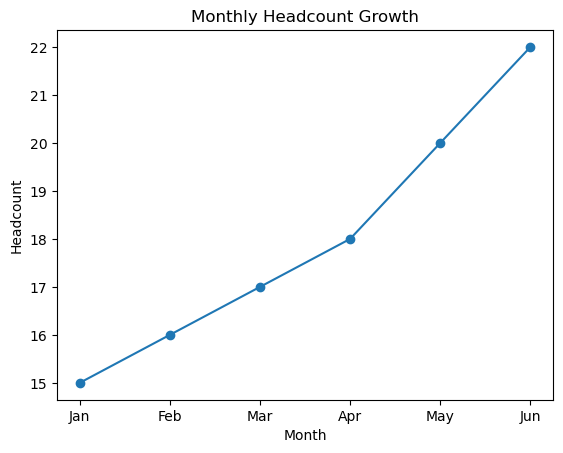

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

employees = pd.read_csv("employees.csv")

# Bar chart

average_salary = employees.groupby("department")["salary"].mean()

plt.bar(average_salary.index, average_salary.values)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()


# A bar chart answers which departments have higher or lower average salaries.


# Scatter plot

sns.scatterplot(
    data=employees,
    x="years_experience",
    y="salary",
    hue="department"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()


# A scatter plot answers whether there is a relationship between experience and salary.


# Histogram

plt.hist(employees["salary"], bins=6)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()


# A histogram answers how the salaries are distributed across different salary ranges.


# Stretch Goal

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
headcount = [15, 16, 17, 18, 20, 22]

plt.plot(months, headcount, marker="o")

plt.title("Monthly Headcount Growth")
plt.xlabel("Month")
plt.ylabel("Headcount")

plt.show()


# A line chart is better for showing a trend because it clearly shows how the value changes over time.

# Task 5 — Consolidation Reflection

### 1. Java habits I had to adjust

* **OOP:** I was used to Java's strict class structure and type declarations, so I had to adjust to Python's dynamic typing, duck typing, and simpler class syntax.
* **FastAPI/Testing:** I was used to Spring Boot annotations and Java-style exception handling, so I had to get used to FastAPI routes, Pydantic models, and Python testing with pytest.
* **Pandas/NumPy:** I was used to processing data with loops in Java, but with NumPy and Pandas I had to think more about vectorized operations, filtering, grouping, and working with entire columns or DataFrames.

### 2. Skill I expect to use again

I expect to use **Pandas and NumPy** again in the upcoming ML/DL modules for preparing datasets before training models. Filtering DataFrames, handling missing values, and using NumPy arrays will be useful when cleaning and transforming training data.

### 3. Least confident topic

I feel least confident with **Pandas groupby, aggregation, and merging**, especially when combining multiple DataFrames and handling missing values. I will practice a few more small datasets using groupby(), agg(), merge(), and missing-value handling before the readiness assessment.


### Task 6

In [6]:
class TrainingRun:

    def __init__(self, model_name, learning_rate):
        self.model_name = model_name
        self.learning_rate = learning_rate

    def __str__(self):
        return f"TrainingRun(model={self.model_name}, lr={self.learning_rate})"


my_run = TrainingRun("CNN", 0.001)
print(my_run)

TrainingRun(model=CNN, lr=0.001)


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()


class User(BaseModel):
    name: str
    age: int


@app.post("/users")
def create_user(user: User):
    return user

In [ ]:
import pandas as pd

df = pd.read_csv("employees.csv")

summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

print(summary)